In [1]:
import scanpy as sc
import seaborn as sns
import harmonypy as hm
import numpy as np

In [27]:
adata = sc.read("../results/adata/09-annotation.h5ad")

In [28]:
adata = adata[adata.obs["cell_type"] == "macrophages"].copy()

In [29]:
adata.X = adata.layers["soupx_rounded"]

In [30]:
adata.obs["sample"].value_counts()

sample
D5_C    2603
D2_C    2415
D5_B    2413
D5_A    2248
D2_D    1312
D7_D     373
D7_C      84
D0_B      47
D0_A      15
Name: count, dtype: int64

In [31]:
print(f"{len(adata.var)} genes before filtering")
sc.pp.filter_genes(adata, min_counts=10)
print(f"{len(adata.var)} genes after filtering")

31656 genes before filtering
21092 genes after filtering


In [32]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

<Axes: ylabel='Count'>

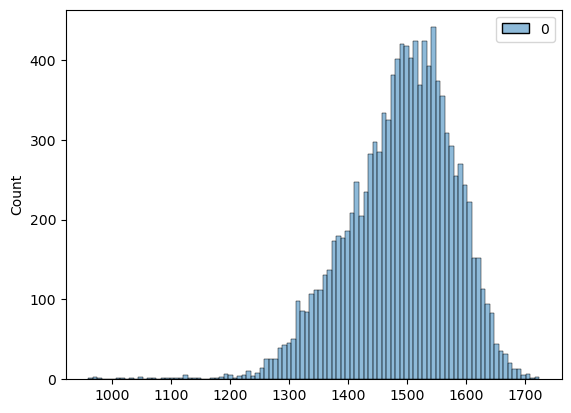

In [33]:
sns.histplot(adata.X.sum(1), bins=100)

In [34]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

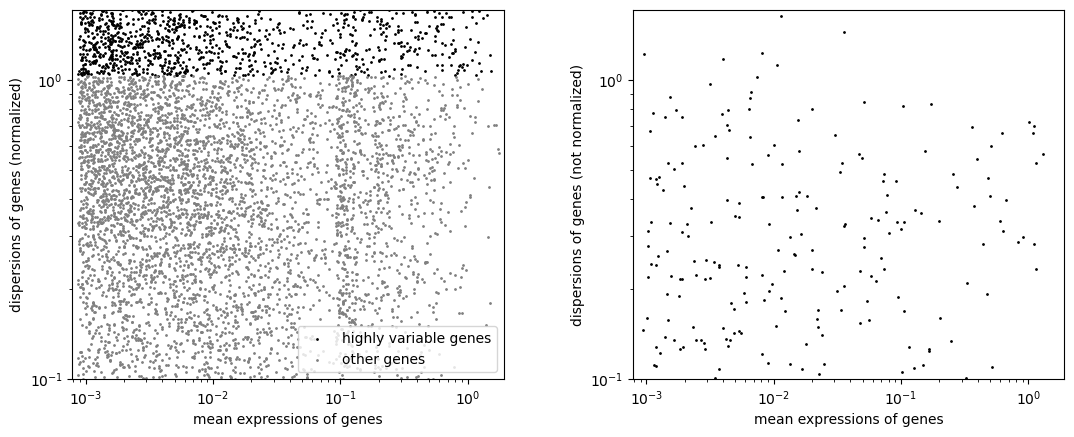

In [35]:
sc.pl.highly_variable_genes(adata, log=True)

In [36]:
sc.pp.pca(adata, svd_solver="arpack", mask_var="highly_variable")

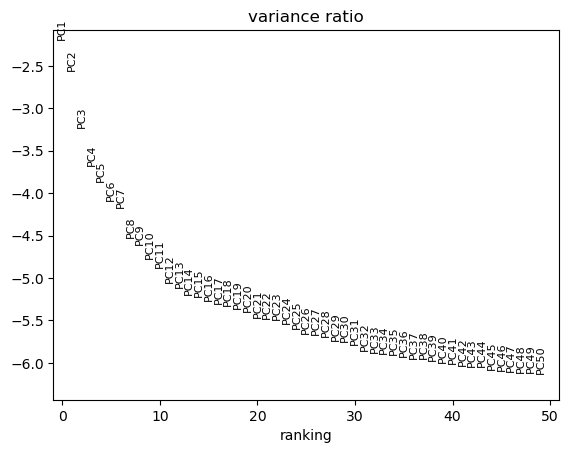

In [37]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

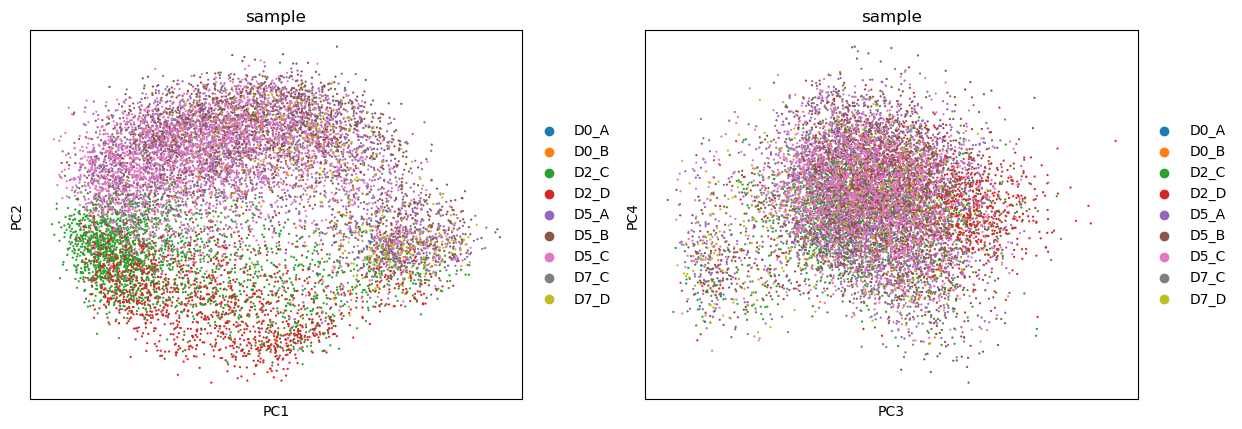

In [38]:
sc.pl.pca_scatter(adata, color="sample", components=["1,2", "3,4"])

In [39]:
harmony_out = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "sample", max_iter_harmony=30)
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr

2026-06-22 15:10:50,966 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-06-22 15:10:50,966 - harmonypy - INFO -   Parameters:
2026-06-22 15:10:50,966 - harmonypy - INFO -     max_iter_harmony: 30
2026-06-22 15:10:50,966 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-22 15:10:50,967 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-22 15:10:50,967 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-22 15:10:50,967 - harmonypy - INFO -     nclust: 100
2026-06-22 15:10:50,967 - harmonypy - INFO -     block_size: 0.05
2026-06-22 15:10:50,968 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-06-22 15:10:50,968 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-06-22 15:10:50,969 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-22 15:10:50,969 - harmonypy - INFO -     verbose: True
2026-06-22 15:10:50,969 - harmonypy - INFO -     random_state: 0
2026-06-22 15:10:50,969 - harmonypy - INFO -   Data: 50 PCs × 11510 cells


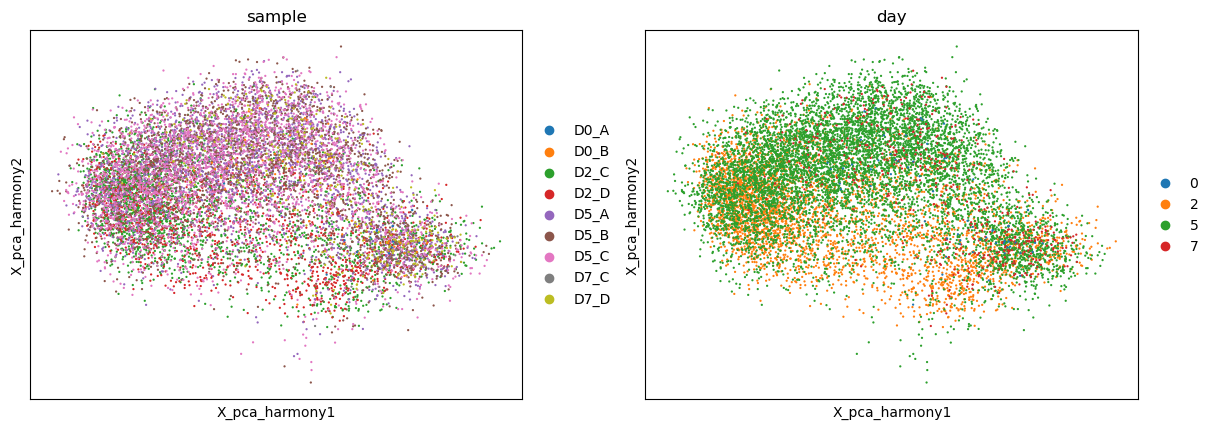

In [40]:
sc.pl.embedding(adata, basis="X_pca_harmony", color=["sample", "day"])

In [41]:
sc.pp.neighbors(adata, n_pcs=40, use_rep='X_pca_harmony')
sc.tl.umap(adata)

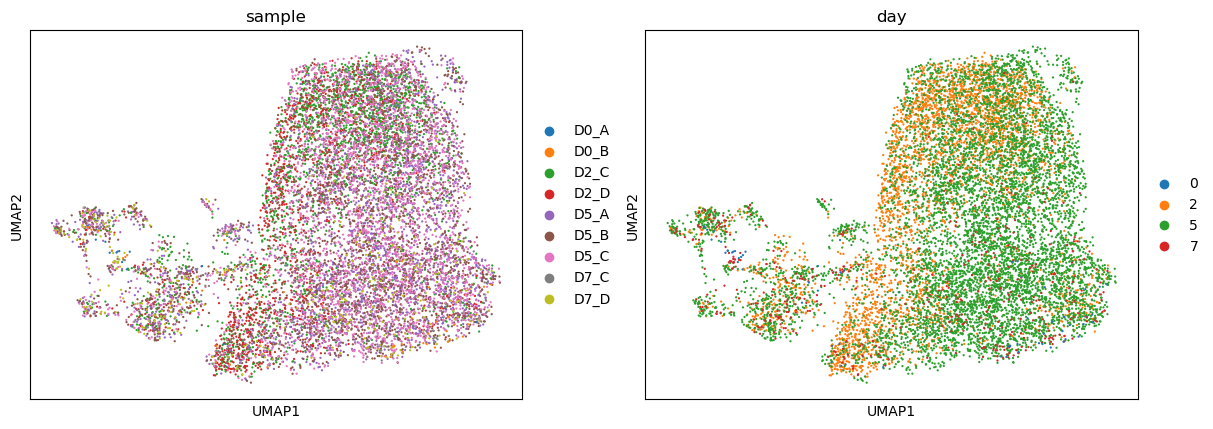

In [42]:
sc.pl.umap(adata, ncols=3, color=["sample", "day"])

In [43]:
sc.tl.leiden(adata, key_added="cluster", resolution=0.25, flavor="igraph")

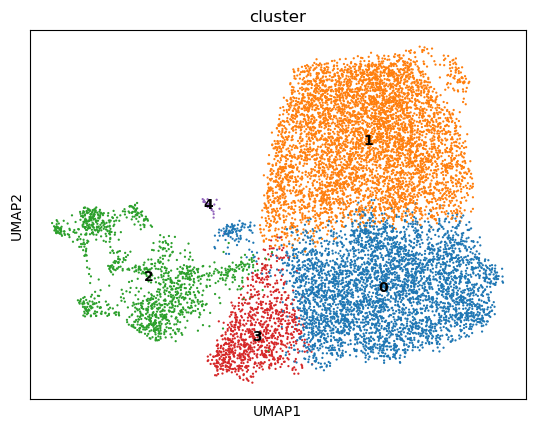

In [44]:
sc.pl.umap(adata, color="cluster", legend_loc="on data")

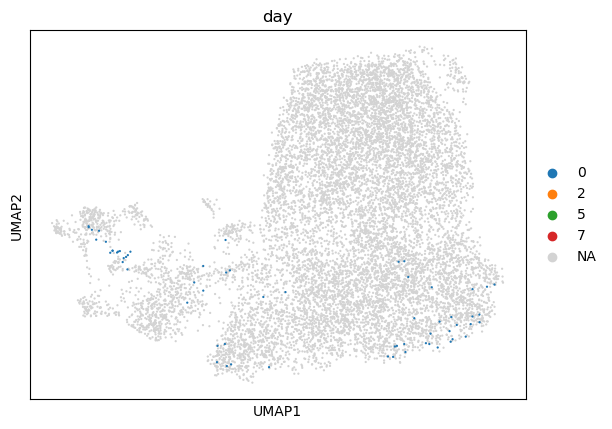

In [20]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 0))

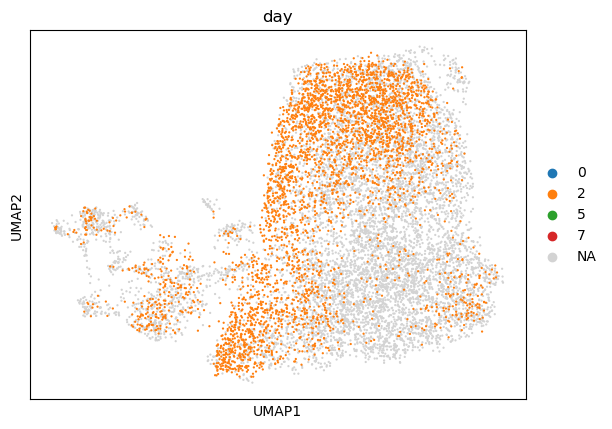

In [21]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 2))

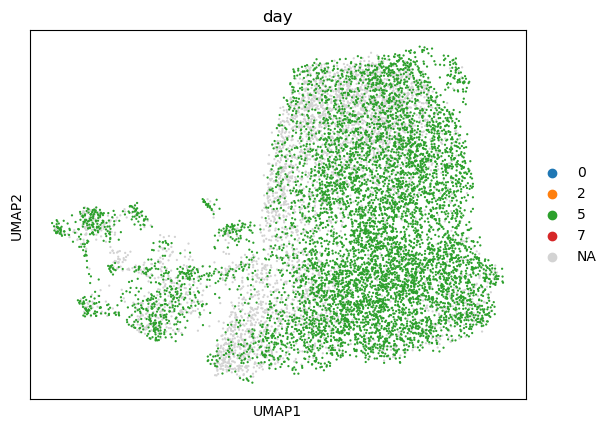

In [22]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 5))

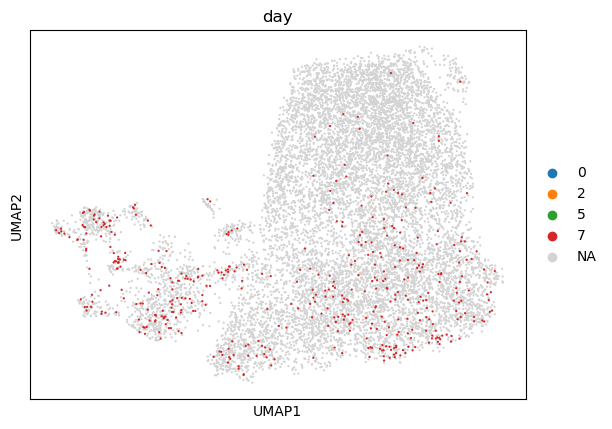

In [23]:
sc.pl.umap(adata, color="day", mask_obs=(adata.obs["day"] == 7))